In [ ]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm

from TraceSimulator import LongTraceSimulator
from OptimumFilter import OptimumFilter
from trace_IO import *  # if you actually need things from here


# -------------------
# Paths & globals
# -------------------
CONFIG_PATH = "/home/dwong/DELight_mtr/trigger_study/wk27/training_config.yaml"

# Template / PSD for OptimumFilter
SUB_TEMPLATE_PATH = "/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/sub_ch_template.npy"
OF_PSD_PATH       = "/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy"

FS = 3_906_250  # Hz

# -------------------
# Simulation config
# -------------------
TOTAL_SETS        = 10         # events per energy
TRACE_SAMPLES     = 50_000
DTYPE             = np.float16

ENERGY            = 0.0
TYPE_RECOIL       = "NR"
PHONON_ONLY       = False
NO_NOISE          = False
QUANTIZE          = True
ROUTE_ALL_SIGNAL_TO_CH0 = False

SUB_START_CH      = 45  # channels >= this are summed for sub-channel


# -------------------
# Helpers
# -------------------
def read_yaml_to_dict(file_path):
    with open(file_path, "r") as file:
        return yaml.safe_load(file)


def write_dict_to_yaml(cfg: dict, file_path: str):
    with open(file_path, "w") as f:
        yaml.safe_dump(cfg, f, sort_keys=False)


def generate_traces_for_noise(noise_power: float):
    """
    Generate TOTAL_SETS traces at fixed ENERGY with given noise_power.
    Also persist noise_power into the YAML before constructing the simulator.

    Returns:
        ts : np.ndarray of shape (TOTAL_SETS, n_channels, TRACE_SAMPLES)
    """
    cfg = read_yaml_to_dict(CONFIG_PATH)
    cfg["noise_power"] = float(noise_power)
    write_dict_to_yaml(cfg, CONFIG_PATH)

    lts = LongTraceSimulator(cfg)
    E_vec = [ENERGY] * TOTAL_SETS

    ts, (x, y, z) = lts.generate(
        E=E_vec,
        x=None, y=None, z=None,
        type_recoil=TYPE_RECOIL,
        phonon_only=PHONON_ONLY,
        no_noise=NO_NOISE,
        quantize=QUANTIZE,
        return_signal_mask=False,
        route_all_signal_to_ch0=ROUTE_ALL_SIGNAL_TO_CH0,
    )

    if ts.shape[0] != TOTAL_SETS:
        raise ValueError("Wrong number of events")
    if ts.shape[2] != TRACE_SAMPLES:
        raise ValueError("Trace length mismatch")

    return np.asarray(ts, dtype=DTYPE)


# -------------------
# Trace plotting (full channel stack; still available if needed)
# -------------------
def plot_traces(traces, fs=3_906_250, offset_step=70, title="QP Traces"):
    if traces.ndim == 3 and traces.shape[0] == 1:
        traces = traces[0]

    num_channels, num_samples = traces.shape
    time_ms = np.arange(num_samples) / fs * 1000

    plt.figure(figsize=(18, 12))

    for i in range(num_channels):
        color = 'orange' if i > 18 else 'tab:blue'
        y = traces[i] + i * offset_step
        plt.plot(time_ms, y, lw=0.4, color=color)
        plt.text(
            time_ms[0] - 0.05 * time_ms[-1],
            y[0],
            f"{i}",
            va="center",
            ha="right",
            fontsize=9,
            color=color,
            fontweight="bold"
        )

    plt.xlabel("Time [ms]", fontsize=16)
    plt.ylabel("Offset ADC counts", fontsize=16)
    plt.title(title, fontsize=18)
    plt.xlim(0, time_ms[-1])
    plt.ylim(-10, offset_step * (num_channels + 1))
    plt.yticks([])
    plt.tight_layout()
    plt.show()


# -------------------
# Optimum Filter Analysis (unchanged)
# -------------------
def analyze_noise_with_OF(ts: np.ndarray, noise_power: float, plot=True):
    sub_template = np.load(SUB_TEMPLATE_PATH)
    noise_psd    = np.load(OF_PSD_PATH)
    worker = OptimumFilter(sub_template, noise_psd, FS)

    sub_traces = ts[:, SUB_START_CH:, :].sum(axis=1)
    noise_trace = sub_traces.reshape(-1).astype(np.float32)

    amps, _ = worker.sliding_fit(
        noise_trace,
        hop=1,
        reanchor_every=None,
        chisq_mode="none",
    )

    amps = amps[np.isfinite(amps)]
    mu, sigma = norm.fit(amps)

    if plot:
        plt.figure(figsize=(6, 4))
        plt.hist(amps, bins=50, density=True)
        x = np.linspace(np.min(amps), np.max(amps), 1000)
        plt.plot(x, norm.pdf(x, mu, sigma), lw=2)
        plt.xlabel("Amplitude")
        plt.ylabel("Density")
        plt.title(f"Noise amplitudes — power {noise_power:.1f}\nμ={mu:.5g}, σ={sigma:.5g}")
        plt.tight_layout()
        plt.show()

    return mu, sigma


# -------------------
# Compare two noise powers: plot first trace + mean/std
# -------------------
def compare_two_noises(noise_power1: float, noise_power2: float, do_OF=False):
    print(f"Generating traces for noise_power = {noise_power1}")
    ts1 = generate_traces_for_noise(noise_power1)

    print(f"Generating traces for noise_power = {noise_power2}")
    ts2 = generate_traces_for_noise(noise_power2)

    # First event only, sub-channel (sum over channels >= SUB_START_CH)
    sub1 = ts1[0, SUB_START_CH:, :].sum(axis=0).astype(np.float32)
    sub2 = ts2[0, SUB_START_CH:, :].sum(axis=0).astype(np.float32)

    # Raw stats
    mean1, std1 = float(np.mean(sub1)), float(np.std(sub1))
    mean2, std2 = float(np.mean(sub2)), float(np.std(sub2))

    print("\n--- Raw sub-channel statistics for first event ---")
    print(f"Noise {noise_power1:6.1f}: mean = {mean1:.6g}, std = {std1:.6g}")
    print(f"Noise {noise_power2:6.1f}: mean = {mean2:.6g}, std = {std2:.6g}")

    # Time axis
    num_samples = sub1.shape[0]
    time_ms = np.arange(num_samples) / FS * 1000.0

    # Plot both traces together
    plt.figure(figsize=(10, 6))
    plt.plot(time_ms, sub1, label=f"noise {noise_power1:.1f}", lw=0.7)
    plt.plot(time_ms, sub2, label=f"noise {noise_power2:.1f}", lw=0.7, alpha=0.8)
    plt.xlabel("Time [ms]")
    plt.ylabel("Sub-channel ADC counts")
    plt.title("First event sub-channel trace for two noise powers")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Optionally also run OF analysis for each set
    if do_OF:
        print("\nRunning OptimumFilter analysis for each noise power...")
        mu1, sigma1 = analyze_noise_with_OF(ts1, noise_power1, plot=True)
        mu2, sigma2 = analyze_noise_with_OF(ts2, noise_power2, plot=True)
        print("\n--- OF amplitude statistics ---")
        print(f"Noise {noise_power1:6.1f}: mu = {mu1:.6g}, sigma = {sigma1:.6g}")
        print(f"Noise {noise_power2:6.1f}: mu = {mu2:.6g}, sigma = {sigma2:.6g}")

    return {
        "noise1": {"power": noise_power1, "mean": mean1, "std": std1},
        "noise2": {"power": noise_power2, "mean": mean2, "std": std2},
    }


# -------------------
# Run
# -------------------
if __name__ == "__main__":
    NOISE1 = 33.2
    NOISE2 = 533.2
    compare_two_noises(NOISE1, NOISE2, do_OF=False)  # set True if you also want OF μ,σ


Generating traces for noise_power = 33.2


In [1]:
import yaml
import numpy as np
from TraceSimulator import LongTraceSimulator
from TraceSimulator import NoiseGenerator
from OptimumFilter import OptimumFilter

import matplotlib.pyplot as plt


def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('/home/dwong/DELight_mtr/trigger_study/wk27/training_config.yaml')
lts = LongTraceSimulator(config)
ng = NoiseGenerator(config)

noise_trace = ng.generate_noise(50_000)
noise_trace32 = noise_trace.astype(np.float32)

plt.plot(noise_trace32)

ModuleNotFoundError: No module named 'yaml'


=== noise_power = 1.0 ===
mean = 0.0271064, std = 1.41307
Gaussian fit: μ = 0.0271064, σ = 1.41307


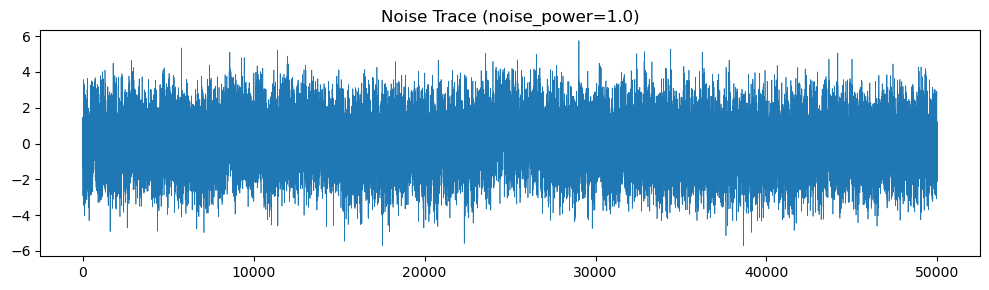

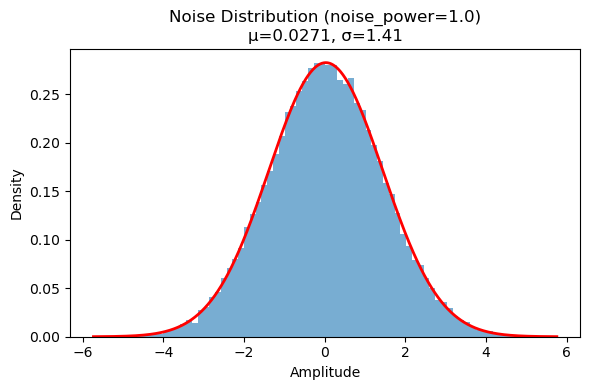


=== noise_power = 5.0 ===
mean = -0.122795, std = 3.15972
Gaussian fit: μ = -0.122795, σ = 3.15972


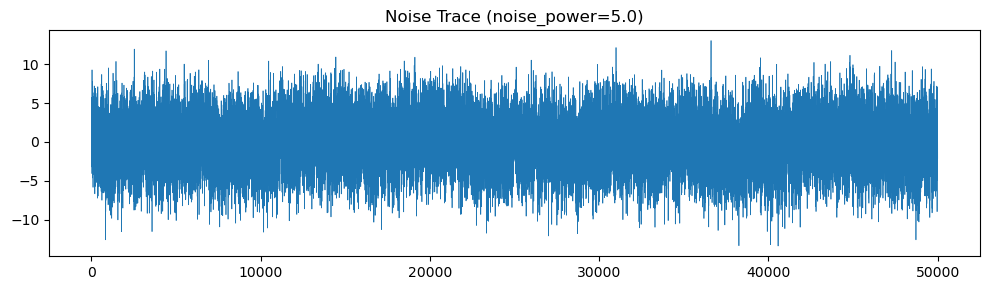

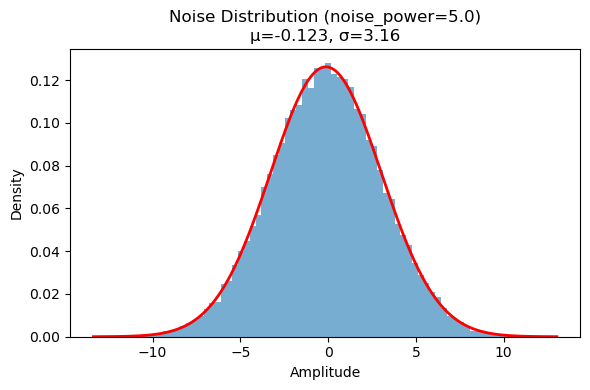


=== noise_power = 10.0 ===
mean = 0.137285, std = 4.46852
Gaussian fit: μ = 0.137285, σ = 4.46852


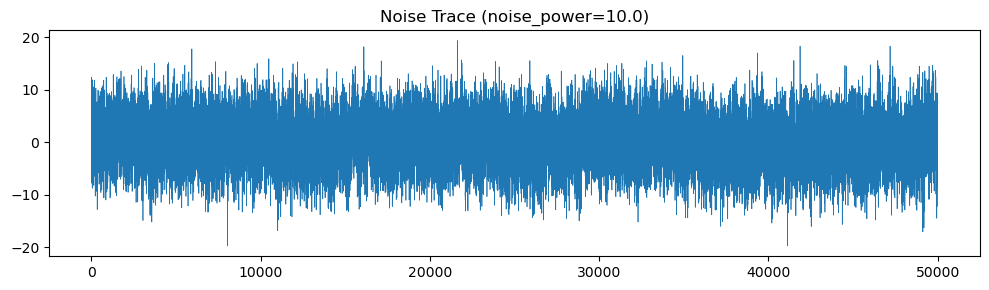

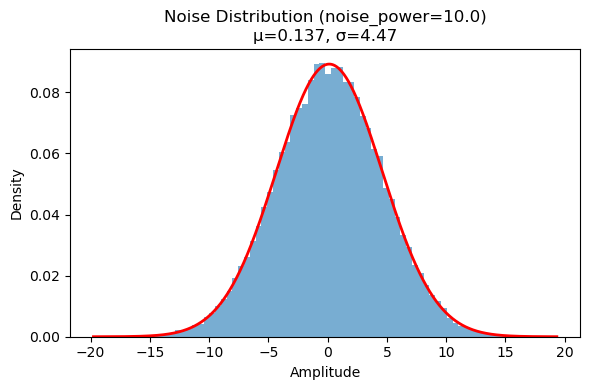


=== noise_power = 20.0 ===
mean = 0.00045013, std = 6.31945
Gaussian fit: μ = 0.00045013, σ = 6.31945


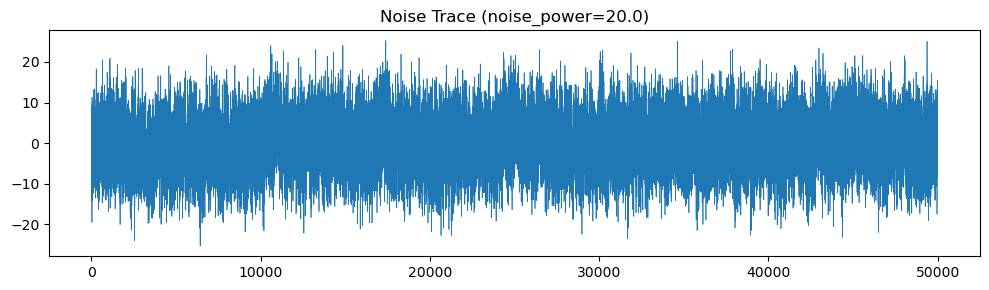

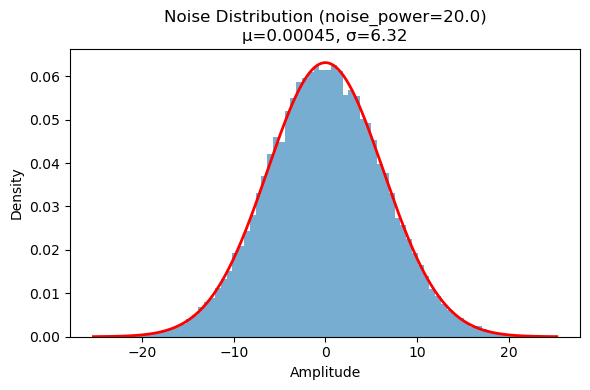


=== noise_power = 50.0 ===
mean = 0.372661, std = 9.99192
Gaussian fit: μ = 0.372661, σ = 9.99192


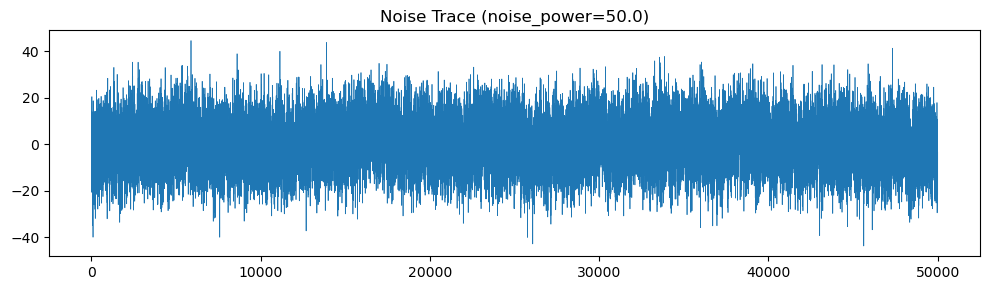

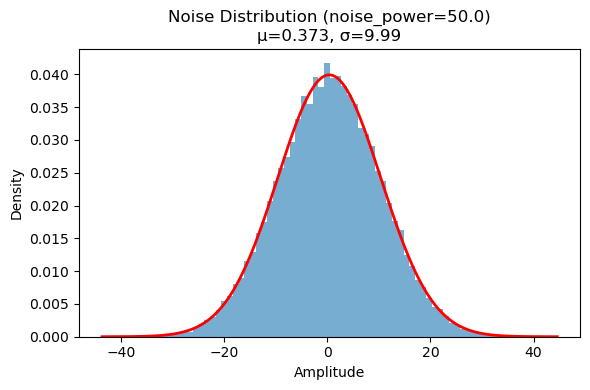


=== noise_power = 100.0 ===
mean = 0.223899, std = 14.1307
Gaussian fit: μ = 0.223899, σ = 14.1307


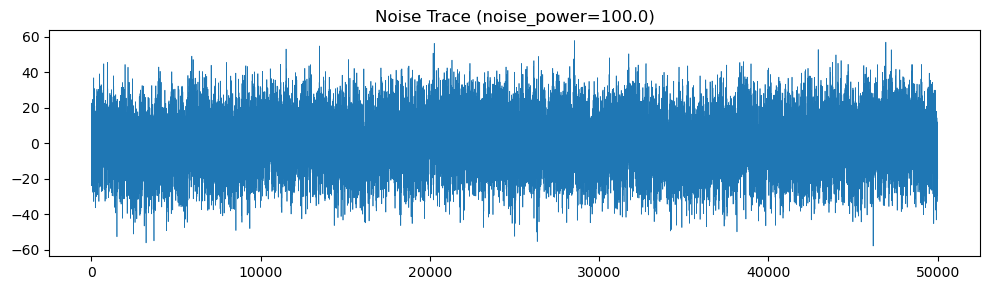

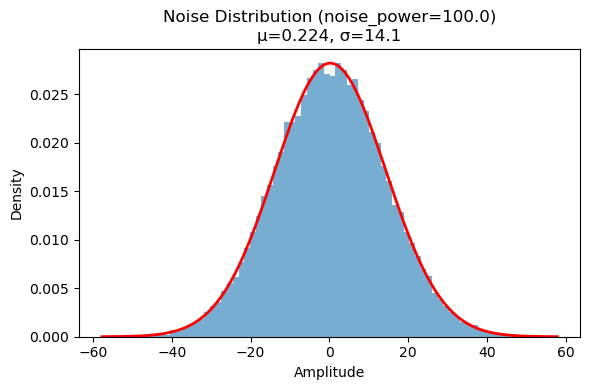


=== noise_power = 200.0 ===
mean = -0.359287, std = 19.9838
Gaussian fit: μ = -0.359287, σ = 19.9838


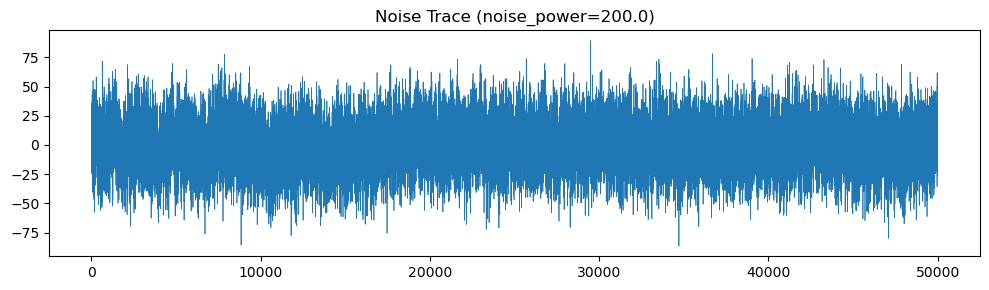

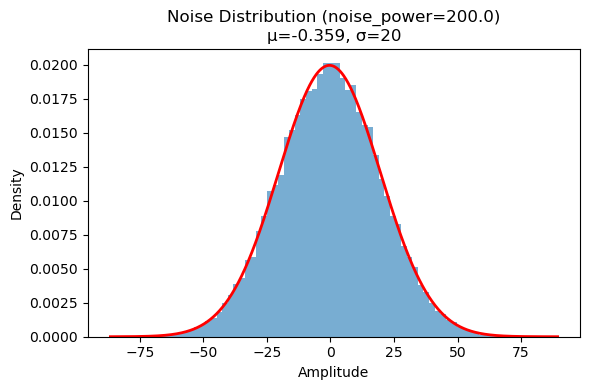


SUMMARY:
noise_power=   1.0 → std=1.413, σ_fit=1.413
noise_power=   5.0 → std=3.16, σ_fit=3.16
noise_power=  10.0 → std=4.469, σ_fit=4.469
noise_power=  20.0 → std=6.319, σ_fit=6.319
noise_power=  50.0 → std=9.992, σ_fit=9.992
noise_power= 100.0 → std=14.13, σ_fit=14.13
noise_power= 200.0 → std=19.98, σ_fit=19.98


In [ ]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from TraceSimulator import  NoiseGenerator


# -------------------
# YAML helpers
# -------------------
def read_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

def write_yaml(cfg, path):
    with open(path, "w") as f:
        yaml.safe_dump(cfg, f, sort_keys=False)


# -------------------
# Generate + analyze noise for given noise_power
# -------------------
def run_noise_test(noise_power, yaml_path, n_samples=50_000):

    # Load + overwrite noise_power
    cfg = read_yaml(yaml_path)
    cfg["noise_power"] = float(noise_power)
    write_yaml(cfg, yaml_path)

    # Re-initialize with updated config
    ng  = NoiseGenerator(cfg)

    # Generate noise trace
    noise = ng.generate_noise(n_samples).astype(np.float32)

    # Stats
    mean = float(np.mean(noise))
    std  = float(np.std(noise))
    mu, sigma = norm.fit(noise)

    print(f"\n=== noise_power = {noise_power} ===")
    print(f"mean = {mean:.6g}, std = {std:.6g}")
    print(f"Gaussian fit: μ = {mu:.6g}, σ = {sigma:.6g}")

    # Plot trace
    plt.figure(figsize=(10, 3))
    plt.plot(noise, lw=0.5)
    plt.title(f"Noise Trace (noise_power={noise_power})")
    plt.tight_layout()
    plt.show()

    # Plot histogram + Gaussian fit
    plt.figure(figsize=(6, 4))
    plt.hist(noise, bins=80, density=True, alpha=0.6)
    x = np.linspace(noise.min(), noise.max(), 1000)
    plt.plot(x, norm.pdf(x, mu, sigma), "r-", lw=2)
    plt.title(f"Noise Distribution (noise_power={noise_power})\nμ={mu:.3g}, σ={sigma:.3g}")
    plt.xlabel("Amplitude"); plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

    return {"mean": mean, "std": std, "mu": mu, "sigma": sigma}


# -------------------
# MAIN: test multiple noise powers
# -------------------
if __name__ == "__main__":
    YAML_PATH = "/home/dwong/DELight_mtr/trigger_study/wk27/training_config.yaml"

    noise_powers = []  # <<< modify here

    results = {}
    for p in noise_powers:
        results[p] = run_noise_test(p, YAML_PATH)

    print("\nSUMMARY:")
    for p, r in results.items():
        print(f"noise_power={p:6.1f} → std={r['std']:.4g}, σ_fit={r['sigma']:.4g}")


Reading YAML...
YAML loaded.
Creating NoiseGenerator...
NoiseGenerator created.
Calling generate_noise...
generate_noise finished.


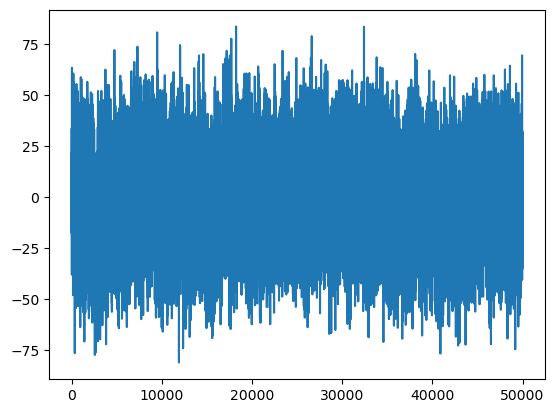

In [2]:
import yaml
import numpy as np
from TraceSimulator import LongTraceSimulator, NoiseGenerator
import matplotlib.pyplot as plt

def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        return yaml.safe_load(file)

print("Reading YAML...", flush=True)
config = read_yaml_to_dict('/home/dwong/DELight_mtr/trigger_study/wk27/training_config.yaml')
print("YAML loaded.", flush=True)


print("Creating NoiseGenerator...", flush=True)
ng = NoiseGenerator(config)
print("NoiseGenerator created.", flush=True)

print("Calling generate_noise...", flush=True)
noise_trace = ng.generate_noise(50_000)
print("generate_noise finished.", flush=True)

noise_trace32 = noise_trace.astype(np.float32)
plt.plot(noise_trace32)
plt.show()



=== noise_power = 1.0 ===
mean = 0.050579, std = 1.41307
Gaussian fit: μ = 0.050579, σ = 1.41307


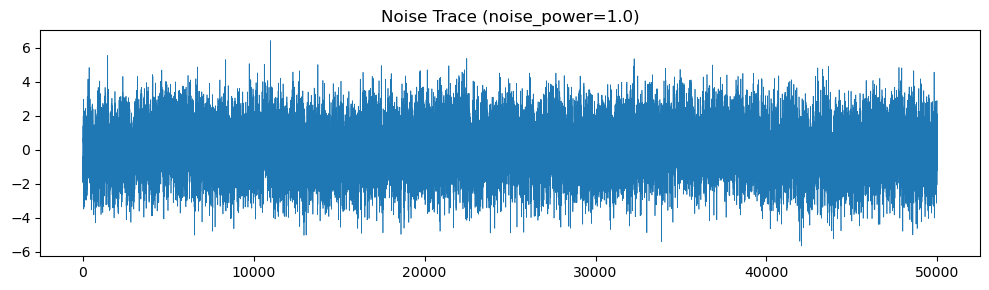

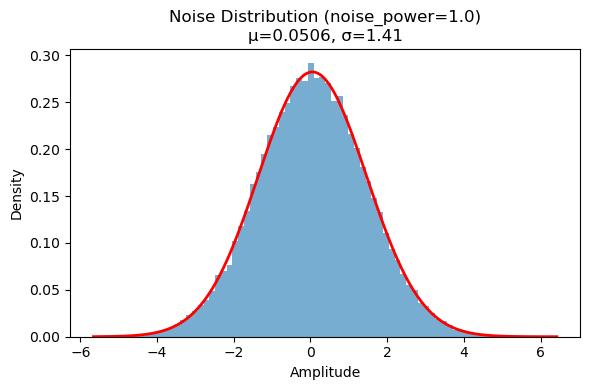


=== noise_power = 5.0 ===
mean = -0.120986, std = 3.15972
Gaussian fit: μ = -0.120986, σ = 3.15972


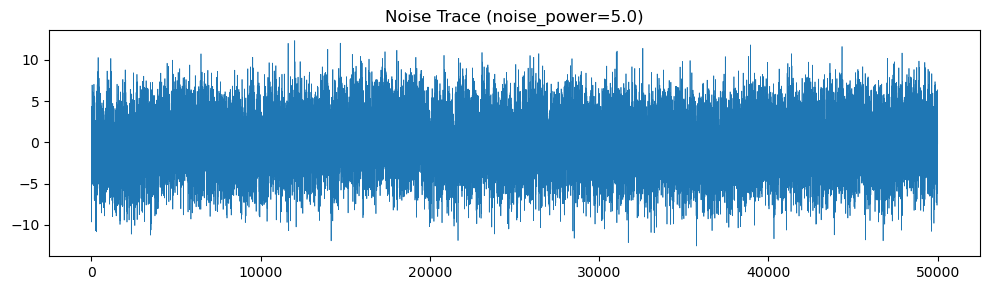

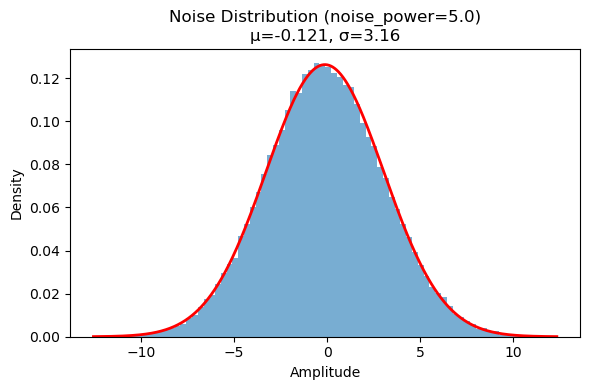


=== noise_power = 10.0 ===
mean = 0.157644, std = 4.46852
Gaussian fit: μ = 0.157644, σ = 4.46852


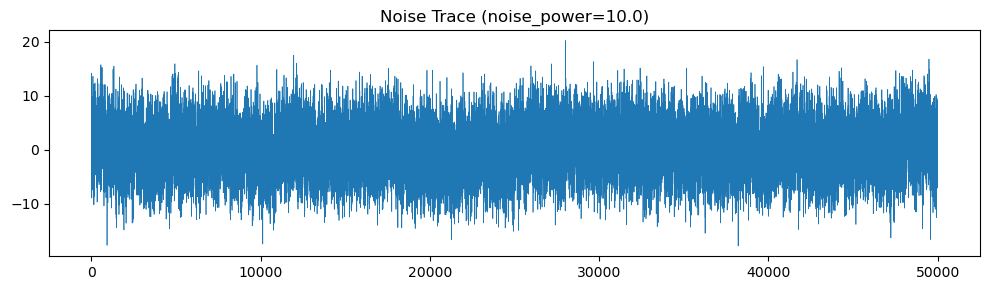

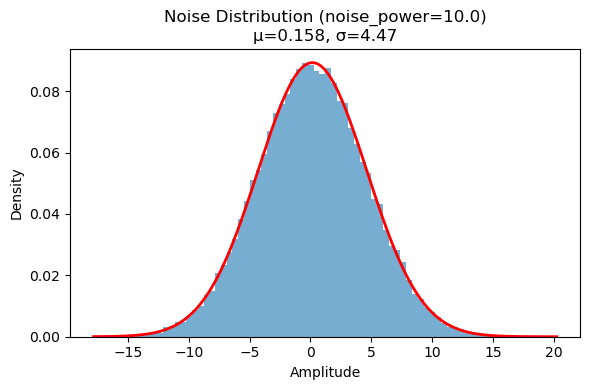


=== noise_power = 20.0 ===
mean = -0.17199, std = 6.31944
Gaussian fit: μ = -0.17199, σ = 6.31944


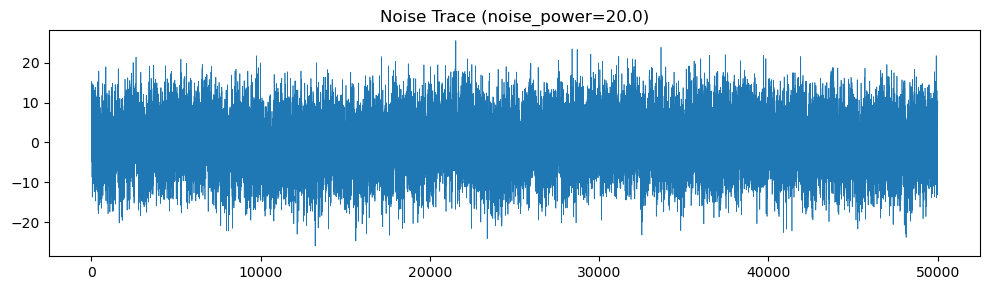

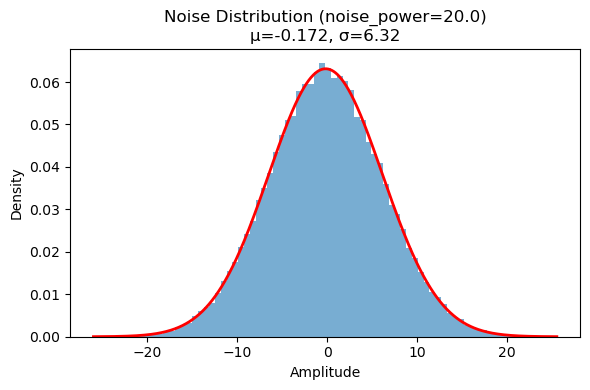


=== noise_power = 50.0 ===
mean = -0.387582, std = 9.99192
Gaussian fit: μ = -0.387582, σ = 9.99192


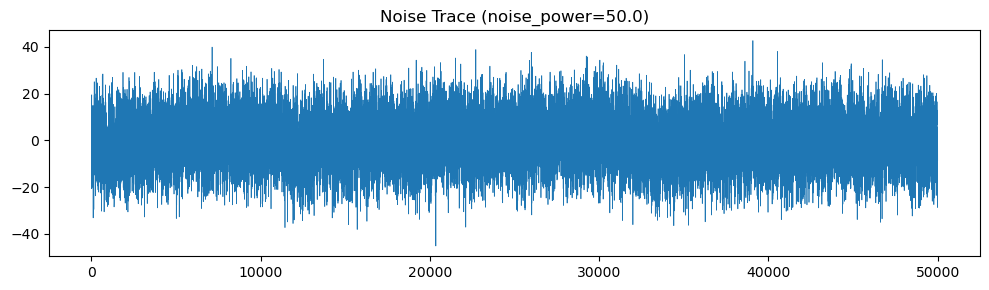

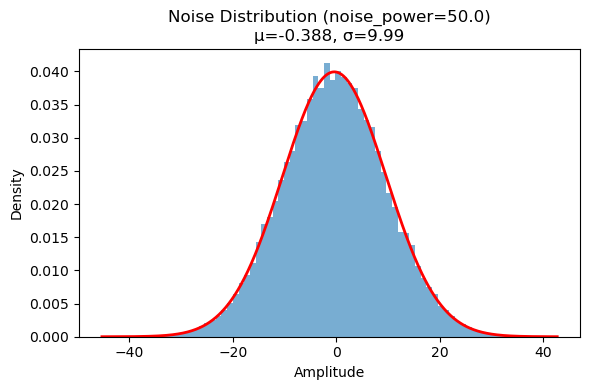


=== noise_power = 100.0 ===
mean = -0.0887371, std = 14.1307
Gaussian fit: μ = -0.0887371, σ = 14.1307


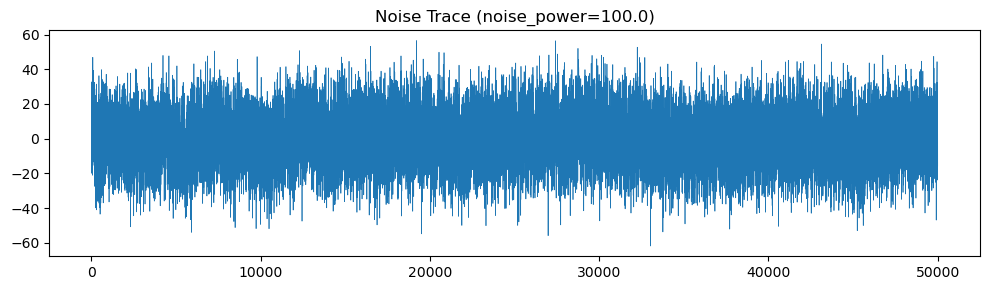

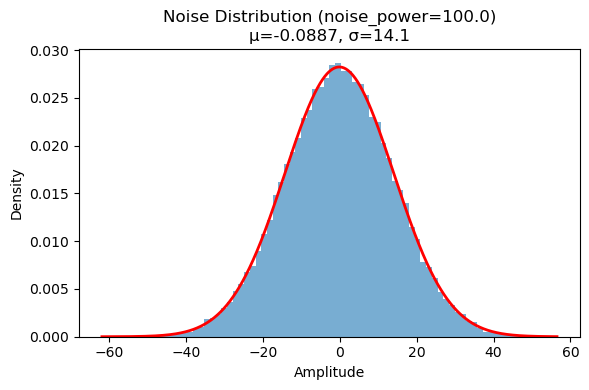


=== noise_power = 200.0 ===
mean = 0.653476, std = 19.9838
Gaussian fit: μ = 0.653476, σ = 19.9838


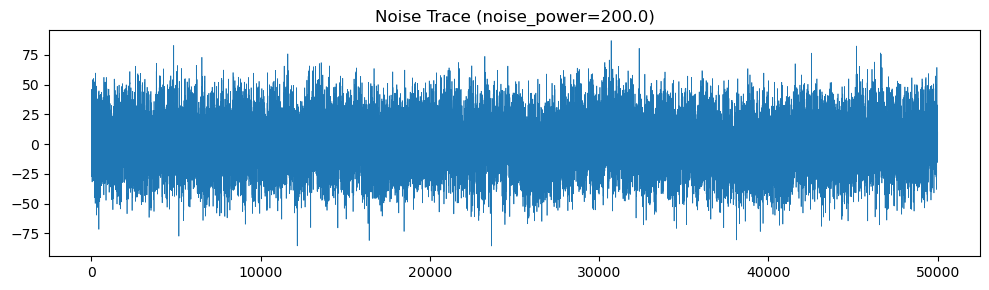

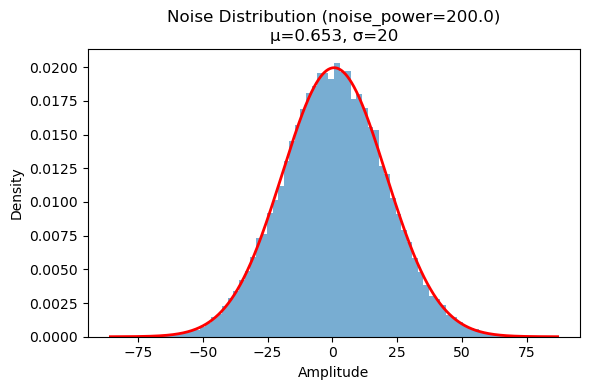


SUMMARY:
noise_power=   1.0 → std=1.413, σ_fit=1.413
noise_power=   5.0 → std=3.16, σ_fit=3.16
noise_power=  10.0 → std=4.469, σ_fit=4.469
noise_power=  20.0 → std=6.319, σ_fit=6.319
noise_power=  50.0 → std=9.992, σ_fit=9.992
noise_power= 100.0 → std=14.13, σ_fit=14.13
noise_power= 200.0 → std=19.98, σ_fit=19.98

FIT: sigma ≈ A * sqrt(noise_power)
A = 1.41307
So: sigma(noise_power) ≈ 1.413 * sqrt(noise_power)

FIT: sigma^2 ≈ k * noise_power + c
k = 1.99677, c = -2.03322e-05


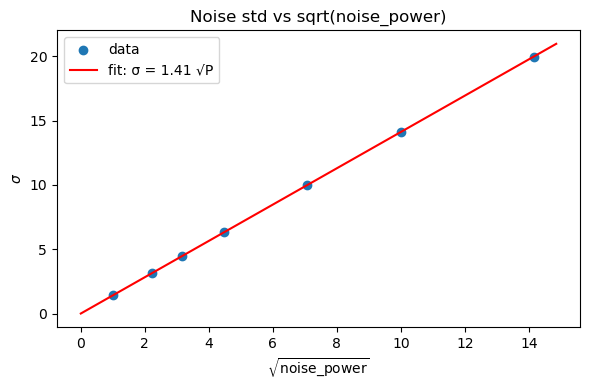

In [2]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from TraceSimulator import NoiseGenerator


# -------------------
# YAML helpers
# -------------------
def read_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

def write_yaml(cfg, path):
    with open(path, "w") as f:
        yaml.safe_dump(cfg, f, sort_keys=False)


# -------------------
# Generate + analyze noise for given noise_power
# -------------------
def run_noise_test(noise_power, yaml_path, n_samples=50_000):

    # Load + overwrite noise_power
    cfg = read_yaml(yaml_path)
    cfg["noise_power"] = float(noise_power)
    write_yaml(cfg, yaml_path)

    # Re-initialize with updated config
    ng  = NoiseGenerator(cfg)

    # Generate noise trace
    noise = ng.generate_noise(n_samples).astype(np.float32)

    # Stats
    mean = float(np.mean(noise))
    std  = float(np.std(noise))
    mu, sigma = norm.fit(noise)

    print(f"\n=== noise_power = {noise_power} ===")
    print(f"mean = {mean:.6g}, std = {std:.6g}")
    print(f"Gaussian fit: μ = {mu:.6g}, σ = {sigma:.6g}")

    # Plot trace
    plt.figure(figsize=(10, 3))
    plt.plot(noise, lw=0.5)
    plt.title(f"Noise Trace (noise_power={noise_power})")
    plt.tight_layout()
    plt.show()

    # Plot histogram + Gaussian fit
    plt.figure(figsize=(6, 4))
    plt.hist(noise, bins=80, density=True, alpha=0.6)
    x = np.linspace(noise.min(), noise.max(), 1000)
    plt.plot(x, norm.pdf(x, mu, sigma), "r-", lw=2)
    plt.title(f"Noise Distribution (noise_power={noise_power})\nμ={mu:.3g}, σ={sigma:.3g}")
    plt.xlabel("Amplitude"); plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

    return {"mean": mean, "std": std, "mu": mu, "sigma": sigma}


# -------------------
# MAIN: test multiple noise powers
# -------------------
if __name__ == "__main__":
    YAML_PATH = "/home/dwong/DELight_mtr/trigger_study/wk27/training_config.yaml"

    noise_powers = [1.0, 5.0, 10.0, 20.0, 50.0, 100.0, 200.0]  # <<< modify here

    results = {}
    for p in noise_powers:
        results[p] = run_noise_test(p, YAML_PATH)

    print("\nSUMMARY:")
    for p, r in results.items():
        print(f"noise_power={p:6.1f} → std={r['std']:.4g}, σ_fit={r['sigma']:.4g}")

    # -------------------
    # FITTING SECTION
    # -------------------
    # arrays of powers and fitted σ
    P = np.array(noise_powers, dtype=float)
    sigma = np.array([results[p]["sigma"] for p in P], dtype=float)

    # 1) Fit σ ≈ A * sqrt(P) (no offset)
    sqrtP = np.sqrt(P)
    # least-squares for single-parameter model:
    A = np.dot(sigma, sqrtP) / np.dot(sqrtP, sqrtP)

    print("\nFIT: sigma ≈ A * sqrt(noise_power)")
    print(f"A = {A:.6g}")
    print("So: sigma(noise_power) ≈ "
          f"{A:.4g} * sqrt(noise_power)")

    # 2) Optional: fit variance linearly in power: σ² ≈ k * P + c
    var = sigma**2
    k, c = np.polyfit(P, var, 1)
    print("\nFIT: sigma^2 ≈ k * noise_power + c")
    print(f"k = {k:.6g}, c = {c:.6g}")

    # 3) Plot σ vs sqrt(P) with fit
    plt.figure(figsize=(6, 4))
    plt.scatter(sqrtP, sigma, label="data")
    xfit = np.linspace(0, sqrtP.max() * 1.05, 200)
    plt.plot(xfit, A * xfit, "r-", label=f"fit: σ = {A:.3g} √P")
    plt.xlabel(r"$\sqrt{\mathrm{noise\_power}}$")
    plt.ylabel(r"$\sigma$")
    plt.title("Noise std vs sqrt(noise_power)")
    plt.legend()
    plt.tight_layout()
    plt.show()



=== noise_power = 15 ===
[time-domain] mean = -0.219803, std = 5.4728
[time-domain] Gaussian fit: μ = -0.219803, σ = 5.4728
[OF amplitude] mean = -0.0100534, std = 0.639016
[OF amplitude] Gaussian fit: μ = -0.0100534, σ = 0.639016
  -> this σ_OF is the one relevant for energy resolution (in OF units)

=== noise_power = 33.2 ===
[time-domain] mean = 0.132329, std = 8.14204
[time-domain] Gaussian fit: μ = 0.132329, σ = 8.14204
[OF amplitude] mean = -0.0146425, std = 0.966728
[OF amplitude] Gaussian fit: μ = -0.0146425, σ = 0.966728
  -> this σ_OF is the one relevant for energy resolution (in OF units)

=== noise_power = 42 ===
[time-domain] mean = -0.342151, std = 9.15774
[time-domain] Gaussian fit: μ = -0.342151, σ = 9.15774
[OF amplitude] mean = 0.0345408, std = 1.0678
[OF amplitude] Gaussian fit: μ = 0.0345408, σ = 1.0678
  -> this σ_OF is the one relevant for energy resolution (in OF units)

=== noise_power = 123 ===
[time-domain] mean = -0.362386, std = 15.6717
[time-domain] Gaussi

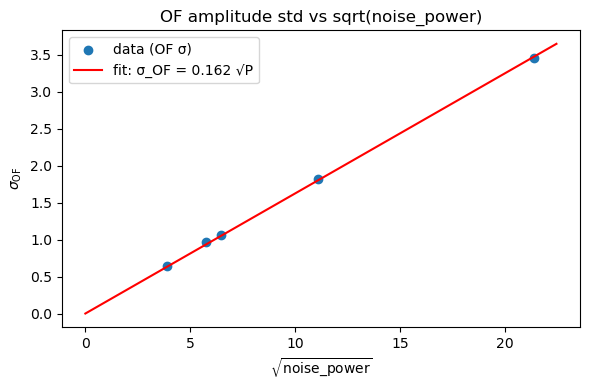

In [4]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from TraceSimulator import NoiseGenerator
from OptimumFilter import OptimumFilter


# -------------------
# YAML helpers
# -------------------
def read_yaml(path):
    with open(path, "r") as f:
        return yaml.safe_load(f)

def write_yaml(cfg, path):
    with open(path, "w") as f:
        yaml.safe_dump(cfg, f, sort_keys=False)


# -------------------
# Generate + analyze noise for given noise_power
#   (time-domain + OptimumFilter amplitudes)
# -------------------
def run_noise_test_with_OF(
    noise_power,
    yaml_path,
    template_path,
    noise_psd_path,
    fs,
    n_samples=50_000,
    n_traces=100,      # number of independent noise traces
    do_plots=True,
):
    # --- Load + overwrite noise_power in YAML ---
    cfg = read_yaml(yaml_path)
    cfg["noise_power"] = float(noise_power)
    write_yaml(cfg, yaml_path)

    # --- Re-initialize NoiseGenerator ---
    ng = NoiseGenerator(cfg)

    # --- Load template + noise PSD, build OptimumFilter ---
    template = np.load(template_path).astype(np.float64)
    noise_psd = np.load(noise_psd_path).astype(np.float64)

    of = OptimumFilter(template, noise_psd, fs)

    # --------------------------
    # 1) Time-domain noise stats
    # --------------------------
    # (single long noise trace, like your original script)
    noise_td = ng.generate_noise(n_samples).astype(np.float32)
    mean_td = float(np.mean(noise_td))
    std_td  = float(np.std(noise_td))
    mu_td, sigma_td = norm.fit(noise_td)

    print(f"\n=== noise_power = {noise_power} ===")
    print(f"[time-domain] mean = {mean_td:.6g}, std = {std_td:.6g}")
    print(f"[time-domain] Gaussian fit: μ = {mu_td:.6g}, σ = {sigma_td:.6g}")

    if do_plots:
        # Plot time-domain trace
        plt.figure(figsize=(10, 3))
        plt.plot(noise_td, lw=0.5)
        plt.title(f"Noise Trace (time domain, noise_power={noise_power})")
        plt.tight_layout()
        plt.show()

        # Histogram + Gaussian fit (time domain)
        plt.figure(figsize=(6, 4))
        plt.hist(noise_td, bins=80, density=True, alpha=0.6)
        x_td = np.linspace(noise_td.min(), noise_td.max(), 1000)
        plt.plot(x_td, norm.pdf(x_td, mu_td, sigma_td), "r-", lw=2)
        plt.title(f"Time-Domain Noise (noise_power={noise_power})\nμ={mu_td:.3g}, σ={sigma_td:.3g}")
        plt.xlabel("Amplitude")
        plt.ylabel("Density")
        plt.tight_layout()
        plt.show()

    # --------------------------------------------
    # 2) OptimumFilter amplitude distribution
    # --------------------------------------------
    # Generate many noise traces, run them through OF, and fit the amplitude distribution.
    all_amps = []

    for i in range(n_traces):
        noise = ng.generate_noise(n_samples).astype(np.float64)
        # sliding_fit gives amplitude vs time; we collect all amplitudes
        amps, _ = of.sliding_fit(noise, hop=1, reanchor_every=None, chisq_mode="none")
        all_amps.append(amps)

    all_amps = np.concatenate(all_amps).astype(np.float64)

    mean_of = float(np.mean(all_amps))
    std_of  = float(np.std(all_amps))
    mu_of, sigma_of = norm.fit(all_amps)

    print(f"[OF amplitude] mean = {mean_of:.6g}, std = {std_of:.6g}")
    print(f"[OF amplitude] Gaussian fit: μ = {mu_of:.6g}, σ = {sigma_of:.6g}")
    print("  -> this σ_OF is the one relevant for energy resolution (in OF units)")

    if do_plots:
        # Histogram of OF amplitudes + Gaussian fit
        plt.figure(figsize=(6, 4))
        plt.hist(all_amps, bins=80, density=True, alpha=0.6)
        x_of = np.linspace(all_amps.min(), all_amps.max(), 1000)
        plt.plot(x_of, norm.pdf(x_of, mu_of, sigma_of), "r-", lw=2)
        plt.title(
            f"OF Amplitude Distribution (noise_power={noise_power})\n"
            f"μ={mu_of:.3g}, σ={sigma_of:.3g}"
        )
        plt.xlabel("OF amplitude")
        plt.ylabel("Density")
        plt.tight_layout()
        plt.show()

    return {
        "time_domain": {"mean": mean_td, "std": std_td, "mu": mu_td, "sigma": sigma_td},
        "of_amplitude": {"mean": mean_of, "std": std_of, "mu": mu_of, "sigma": sigma_of},
    }


# -------------------
# MAIN: test multiple noise powers
# -------------------
if __name__ == "__main__":
    YAML_PATH       = "/home/dwong/DELight_mtr/trigger_study/wk27/training_config.yaml"
    TEMPLATE_PATH   = "/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/vac_ch_template.npy"
    NOISE_PSD_PATH  = "/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy"
    FS              = 3_906_250

    # Your full noise-power set:
    noise_powers = [15, 33.2, 42, 123, 458]

    results = {}
    for p in noise_powers:
        results[p] = run_noise_test_with_OF(
            noise_power=p,
            yaml_path=YAML_PATH,
            template_path=TEMPLATE_PATH,
            noise_psd_path=NOISE_PSD_PATH,
            fs=FS,
            n_samples=50_000,
            n_traces=200,
            do_plots=False,   # turn on if you want per-noise plots
        )

    print("\nSUMMARY (time domain):")
    for p, r in results.items():
        td = r["time_domain"]
        print(f"noise_power={p:6.2f} → std={td['std']:.4g}, σ_fit={td['sigma']:.4g}")

    print("\nSUMMARY (OF amplitude):")
    for p, r in results.items():
        of = r["of_amplitude"]
        print(f"noise_power={p:6.2f} → std_OF={of['std']:.4g}, σ_OF_fit={of['sigma']:.4g}")

    # -------------------
    # FITTING SECTION (using OF amplitude σ)
    # -------------------
    P = np.array(noise_powers, dtype=float)
    sigma_of = np.array([results[p]["of_amplitude"]["sigma"] for p in P], dtype=float)

    sqrtP = np.sqrt(P)
    A = np.dot(sigma_of, sqrtP) / np.dot(sqrtP, sqrtP)

    print("\nFIT (OF amplitude): sigma_OF ≈ A * sqrt(noise_power)")
    print(f"A = {A:.6g}")
    print("So: sigma_OF(noise_power) ≈ "
          f"{A:.4g} * sqrt(noise_power)")

    # Optional: variance fit
    var_of = sigma_of**2
    k, c = np.polyfit(P, var_of, 1)
    print("\nFIT (OF amplitude): sigma_OF^2 ≈ k * noise_power + c")
    print(f"k = {k:.6g}, c = {c:.6g}")

    # Plot σ_OF vs sqrt(P) with fit
    plt.figure(figsize=(6, 4))
    plt.scatter(sqrtP, sigma_of, label="data (OF σ)")
    xfit = np.linspace(0, sqrtP.max() * 1.05, 200)
    plt.plot(xfit, A * xfit, "r-", label=f"fit: σ_OF = {A:.3g} √P")
    plt.xlabel(r"$\sqrt{\mathrm{noise\_power}}$")
    plt.ylabel(r"$\sigma_{\mathrm{OF}}$")
    plt.title("OF amplitude std vs sqrt(noise_power)")
    plt.legend()
    plt.tight_layout()
    plt.show()


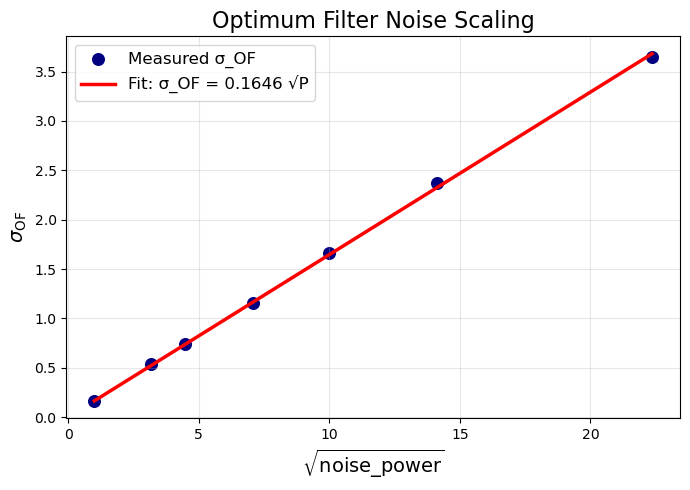

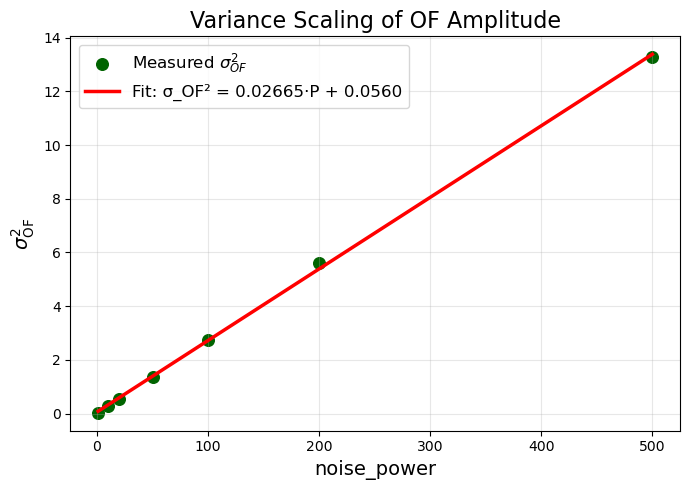


===== RESULTS =====
A (σ_OF = A√P) = 0.164597
Correlation corr(σ_OF, √P) = 0.999835
R² of σ_OF model = 0.999594

Variance fit:
k (slope) = 0.026651, c (intercept) = 0.056025
Correlation corr(σ_OF², P) = 0.999759


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Data from your measurement
# --------------------------
noise_power = np.array([1, 10, 20, 50, 100, 200, 500], dtype=float)
sigma_of = np.array([0.162656, 0.541489, 0.743947, 1.15851, 1.66006, 2.36812, 3.64591], dtype=float)

sqrtP = np.sqrt(noise_power)
sigma2 = sigma_of**2

# --------------------------
# Fit: sigma_OF = A * sqrt(P)
# --------------------------
A = np.dot(sigma_of, sqrtP) / np.dot(sqrtP, sqrtP)
sigma_fit = A * sqrtP

# R^2
ss_res = np.sum((sigma_of - sigma_fit)**2)
ss_tot = np.sum((sigma_of - np.mean(sigma_of))**2)
R2 = 1 - ss_res/ss_tot

# Pearson correlation
corr_sigma_sqrtP = np.corrcoef(sigma_of, sqrtP)[0, 1]

# --------------------------
# Fit: sigma_OF^2 = k P + c
# --------------------------
k, c = np.polyfit(noise_power, sigma2, 1)
sigma2_fit = k * noise_power + c

corr_sigma2_P = np.corrcoef(sigma2, noise_power)[0, 1]


# ==========================
# ---- Plot σ_OF vs √P ----
# ==========================
plt.figure(figsize=(7,5))
plt.scatter(sqrtP, sigma_of, s=70, label="Measured σ_OF", color="navy")
plt.plot(sqrtP, sigma_fit, "r-", lw=2.5, label=f"Fit: σ_OF = {A:.4f} √P")

plt.xlabel(r"$\sqrt{\mathrm{noise\_power}}$", fontsize=14)
plt.ylabel(r"$\sigma_{\mathrm{OF}}$", fontsize=14)
plt.title("Optimum Filter Noise Scaling", fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# ==============================
# ---- Plot σ_OF^2 vs P ----
# ==============================
plt.figure(figsize=(7,5))
plt.scatter(noise_power, sigma2, s=70, label=r"Measured $\sigma_{OF}^2$", color="darkgreen")
plt.plot(noise_power, sigma2_fit, "r-", lw=2.5,
         label=f"Fit: σ_OF² = {k:.5f}·P + {c:.4f}")

plt.xlabel("noise_power", fontsize=14)
plt.ylabel(r"$\sigma_{\mathrm{OF}}^2$", fontsize=14)
plt.title("Variance Scaling of OF Amplitude", fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


# ==========================
# ---- Print Results ----
# ==========================
print("\n===== RESULTS =====")
print(f"A (σ_OF = A√P) = {A:.6f}")
print(f"Correlation corr(σ_OF, √P) = {corr_sigma_sqrtP:.6f}")
print(f"R² of σ_OF model = {R2:.6f}")

print("\nVariance fit:")
print(f"k (slope) = {k:.6f}, c (intercept) = {c:.6f}")
print(f"Correlation corr(σ_OF², P) = {corr_sigma2_P:.6f}")
